In [41]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

import seaborn as sns 

from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 
from sklearn.preprocessing import StandardScaler 
from sklearn.svm import SVC 

In [42]:
# Load dataset
data = pd.read_csv("./titanic/train.csv")

In [43]:
# Data preprocessing
data["Age"] = data["Age"].fillna(data["Age"].median())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

In [44]:
# Converting text to numbers
data["Sex"] = data["Sex"].replace({"male": 0, "female": 1}).astype(int) 
data["Embarked"] = data["Embarked"].replace({"C": 0, "Q": 1, "S": 2}).astype(int)
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,2


In [45]:
# Discretization for Naive Bayes 
data["Age"] = pd.cut(data["Age"], bins=5, labels=False) 
data["Fare"] = pd.cut(data["Fare"], bins=5, labels=False)

In [46]:
# Feature selection
data = data[["Survived", "Pclass", "Sex", "Age", "Fare", "Embarked"]]
x = data.drop("Survived", axis=1)
y = data["Survived"]
data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,0,1,0,2
1,1,1,1,2,0,0
2,1,3,1,1,0,2
3,1,1,1,2,0,2
4,0,3,0,2,0,2


In [47]:
# Train/test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=50)


train_data = x_train.copy() 
train_data["Survived"] = y_train

In [48]:
# Naive Bayes
alpha = 1 # Laplace smoothing

# Basic probabilities
Psurvived= train_data["Survived"].value_counts()[1] / train_data.shape[0]
Pdead = train_data["Survived"].value_counts()[0] / train_data.shape[0]


In [49]:
# size of dictionary = number of unique values in all features
features = ["Pclass", "Sex", "Age", "Fare", "Embarked"]

Nvoc = sum(train_data[f].nunique() for f in features)

In [50]:

# probability function
def p_x_given_survived(feature, value):
    subset = train_data[train_data["Survived"] == 1]
    count = subset[subset[feature] == value].shape[0]
    total = subset.shape[0]
    return (count + alpha) / (total + alpha * train_data[feature].nunique())

def p_x_given_dead(feature, value):
    subset = train_data[train_data["Survived"] == 0]
    count = subset[subset[feature] == value].shape[0]
    total = subset.shape[0]
    return (count + alpha) / (total + alpha * train_data[feature].nunique())

In [51]:

# row classification
def classify(row):
    p_surv = Psurvived
    p_dead = Pdead
    
    for f in features:
        value = row[f]
        p_surv *= p_x_given_survived(f, value)
        p_dead *= p_x_given_dead(f, value)
    
    if p_surv > p_dead:
        return 1
    else:
        return 0

In [52]:
# dataset application
train_data["Predicted"] = train_data.apply(classify, axis=1)


In [53]:
# calculate accuracy
accuracy = ((train_data["Predicted"] == train_data["Survived"]).sum() / train_data.shape[0]) * 100
print("Naive Bayes accuracy:", accuracy)

Naive Bayes accuracy: 79.07303370786516


In [54]:
# Normalization
scaler = StandardScaler() 
x_train_scaled = scaler.fit_transform(x_train) 
x_test_scaled = scaler.transform(x_test)

In [56]:
# SVM
svm_model = SVC(kernel='rbf', C=1)
svm_model.fit(x_train_scaled, y_train)

svm_pred = svm_model.predict(x_test_scaled)

print("\nSVM results:")
print("Accuracy:", accuracy_score(y_test, svm_pred) * 100)


SVM results:
Accuracy: 78.2122905027933


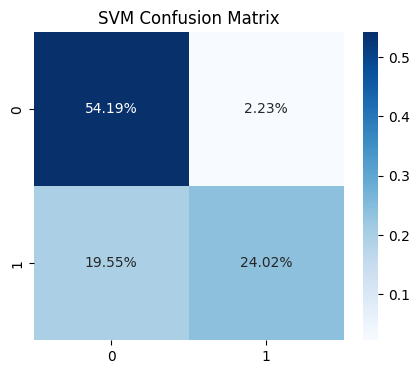

              precision    recall  f1-score   support

           0       0.73      0.96      0.83       101
           1       0.91      0.55      0.69        78

    accuracy                           0.78       179
   macro avg       0.82      0.76      0.76       179
weighted avg       0.81      0.78      0.77       179



In [57]:
# Evaluation
cf_matrix = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, fmt=".2%", cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()

print(classification_report(y_test, svm_pred))